In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.datasets import make_blobs
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=3 ,random_state=23)

In [3]:
X.shape

(1000, 2)

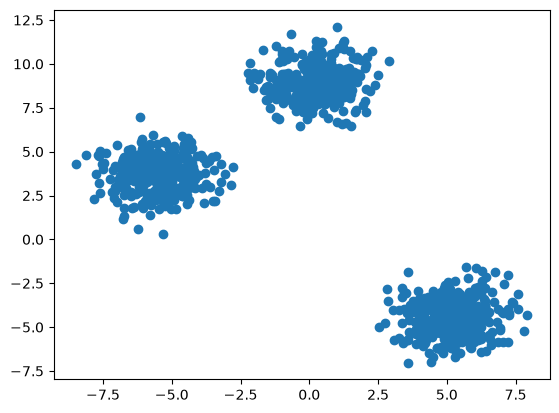

In [4]:
plt.scatter(X[:,0],X[:,1])

In [5]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.33)

In [6]:
from sklearn.cluster import KMeans

### First lets find k values through ELbow methods 
wcss=(distance between points to the nearest centroid)^2

In [7]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [8]:
wcss

[34827.57682552022,
 7935.437286145416,
 1319.2730531585607,
 1181.4952002962868,
 1004.5196452913926,
 908.9107220161447,
 786.1426621094396,
 679.4187189389488,
 616.2963508420694,
 544.6964687542126]

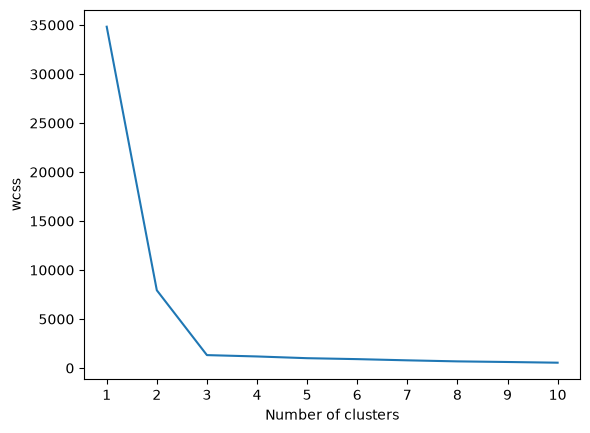

In [9]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("wcss")
plt.show()


from Elbow Method we find k value k=3

In [10]:
#train data 
model=KMeans(n_clusters=3,init='k-means++')
label=model.fit_predict(X_train)


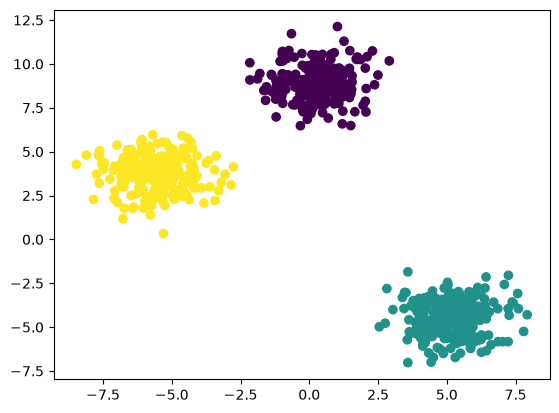

In [11]:
#train data
plt.scatter(X_train[:,0],X_train[:,1],c=label)

In [12]:
#test data
y_test_label=model.predict(X_test)
y_test_label

array([0, 0, 0, 1, 2, 0, 1, 1, 2, 1, 0, 0, 2, 1, 0, 1, 1, 0, 2, 0, 0, 0,
       1, 0, 0, 1, 2, 0, 2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 2, 2, 0, 2, 2, 0,
       1, 2, 1, 0, 0, 1, 2, 0, 1, 0, 2, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 1,
       1, 0, 2, 2, 0, 0, 2, 1, 1, 0, 1, 1, 0, 0, 2, 2, 1, 2, 1, 1, 2, 0,
       1, 0, 2, 0, 2, 0, 2, 1, 0, 1, 2, 1, 1, 2, 0, 1, 2, 1, 2, 2, 1, 1,
       2, 2, 1, 2, 1, 2, 2, 0, 2, 2, 2, 2, 1, 2, 1, 1, 2, 0, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 1, 0, 0, 2, 2, 2, 0, 2, 2, 1, 1, 1, 1, 0, 2, 2, 0,
       0, 2, 0, 0, 1, 1, 0, 0, 1, 1, 2, 0, 1, 1, 0, 0, 0, 2, 0, 0, 2, 2,
       2, 1, 1, 0, 1, 2, 1, 0, 2, 2, 1, 2, 1, 0, 2, 1, 2, 2, 2, 1, 2, 2,
       1, 1, 0, 0, 1, 0, 1, 2, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2,
       1, 0, 2, 1, 2, 0, 0, 2, 0, 0, 0, 0, 2, 1, 2, 2, 1, 0, 1, 0, 2, 0,
       0, 2, 0, 1, 0, 0, 2, 0, 1, 1, 1, 0, 1, 2, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 2, 0, 1, 1, 2, 1, 2, 2, 2, 1, 0, 2, 0, 2, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 1, 1, 0,

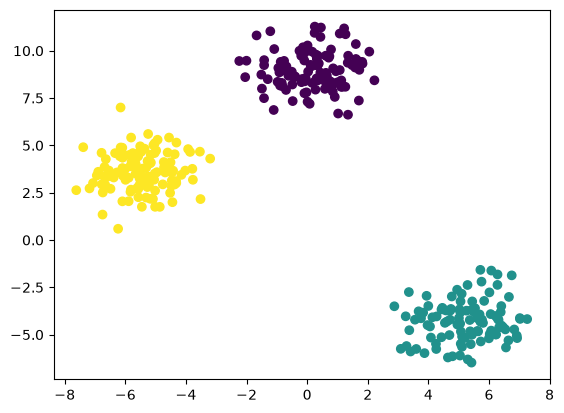

In [13]:
# test data 
plt.scatter(X_test[:,0],X_test[:,1],c=y_test_label)

lets again lets check from knee locater 
we did manaully for Elbow method if we got larger data if will be more difficult to find k values no of cluster

In [14]:
from kneed import KneeLocator

In [15]:
#if our wcss is deceasing we used convex and direction decresing 
#if our wcss is increaing we used concave 
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

so we got from kneelocator the value of k =3 

### Silhouette score 
lets check the performance metrics of the model 

In [16]:
from sklearn.metrics import silhouette_score
silhouette=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train)
    score=silhouette_score(X_train,kmeans.labels_)
    silhouette.append(score)

In [17]:
silhouette

[0.7281443868598331,
 0.8071181203797672,
 0.6357733426488265,
 0.6324388543217302,
 0.4784403252494855,
 0.3258529700078003,
 0.3277563402431081,
 0.34573249432303466,
 0.30698884788787656]

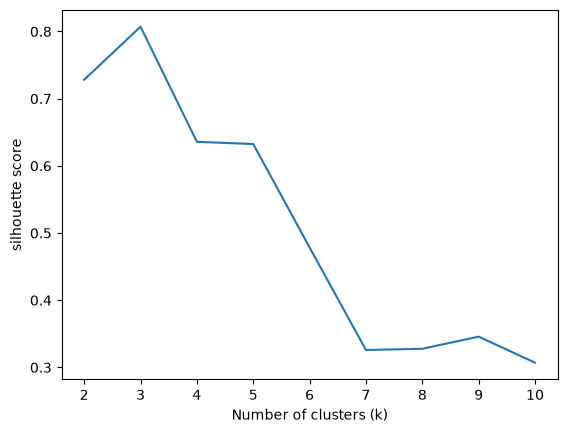

In [18]:
plt.plot(range(2,11),silhouette)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters (k)")
plt.ylabel("silhouette score")
plt.show()

silhouette values is from range(-1 to +1) the value more close to 1 is more better of clustering